## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## Preguntas

1. ¿Cuál es la variable objetivo?
2. ¿Qué representa dicha variable?
3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
4. ¿Cuántas variables predictoras existen?
5. ¿Por qué fue necesario transformar variables categóricas?
7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
8. ¿Existen valores nulos?
9. ¿Qué variables son numéricas?
10. ¿Qué variables son categóricas?
11. ¿Cuántos registros quedaron en entrenamiento?
12. ¿Cuántos registros quedaron en prueba?
13. ¿Por qué no debemos entrenar utilizando todos los datos?
14. ¿Cuál fue el Accuracy obtenido?
15. ¿Consideras que el resultado es adecuado?
16. ¿Qué factores podrían afectar el desempeño del modelo?
18. ¿Cuál fue la variable más importante?
19. ¿Cuál fue la menos importante?
20. ¿Coinciden los resultados con tus hipótesis iniciales?
21. ¿Qué variables aportan más información al modelo?


# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---


## Parte 1. Importación de librerías

In [1]:
#Importamos Librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub

## Parte 2. Carga del dataset

In [3]:
path = kagglehub.dataset_download("uciml/adult-census-income")

In [4]:
print("Ruta del dataset:", path)

Ruta del dataset: C:\Users\Ale\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3


In [5]:
dfCensus = pd.read_csv(path + "/adult.csv")

In [6]:
dfCensus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
dfCensus.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Parte 3. Comprensión del problema
Determinar si una persona tiene un ingreso anual superior a $50,000 dólares (>50K) o no (<=50K), a partir de sus características demográficas y laborales.

income
<=50K - La persona gana 50,000 dólares anuales o menos
>50K - La persona gana más de 50,000 dólares anuales

In [9]:
dfCensus["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

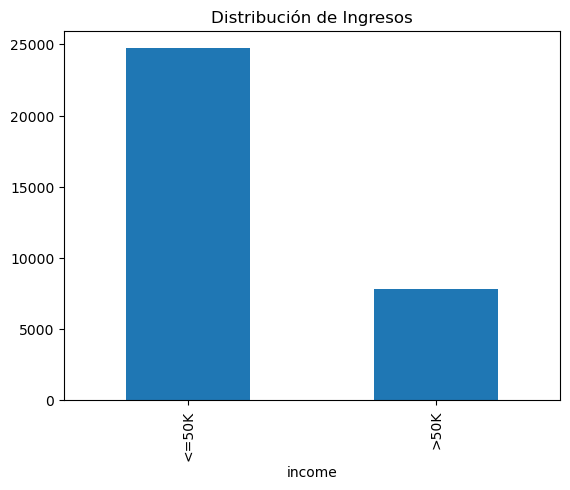

In [10]:
#Graficamos
dfCensus["income"].value_counts().plot(
    kind="bar"
)
plt.title("Distribución de Ingresos")
plt.show()

## Parte 4. Exploración inicial (EDA)

In [8]:
dfCensus.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [12]:
#Hipotesis inicial: la educacion influye en el ingreso
dfCensus.groupby(
    "education"
)["income"].apply(lambda x: (x == ">50K").mean()).sort_values(ascending=False)

education
Doctorate       0.740920
Prof-school     0.734375
Masters         0.556587
Bachelors       0.414753
Assoc-voc       0.261216
Assoc-acdm      0.248360
Some-college    0.190235
HS-grad         0.159509
12th            0.076212
10th            0.066452
7th-8th         0.061920
9th             0.052529
11th            0.051064
5th-6th         0.048048
1st-4th         0.035714
Preschool       0.000000
Name: income, dtype: float64

In [13]:
#Hipotesis inicial: el sexo influye en el ingreso
dfCensus.groupby(
    "sex"
)["income"].apply(lambda x: (x == ">50K").mean())

sex
Female    0.109461
Male      0.305737
Name: income, dtype: float64

In [14]:
#Hipotesis inicial: el estado civil influye en el ingreso
dfCensus.groupby(
    "marital.status"
)["income"].apply(lambda x: (x == ">50K").mean()).sort_values(ascending=False)

marital.status
Married-civ-spouse       0.446848
Married-AF-spouse        0.434783
Divorced                 0.104209
Widowed                  0.085599
Married-spouse-absent    0.081340
Separated                0.064390
Never-married            0.045961
Name: income, dtype: float64

## Parte 5. Correlación e Hipótesis

Creamos una matriz de correlación para identificar la relación lineal entre las variables numéricas. No identifica la importancia de variables en el modelo.

Para poder incluir la variable objetivo en la matriz, generamos una versión numérica temporal de income (0 = <=50K, 1 = >50K), únicamente para este análisis.

In [15]:
variables_numericas = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [16]:
#Version numerica temporal de la variable objetivo, solo para la matriz de correlacion
income_num = dfCensus["income"].map({"<=50K": 0, ">50K": 1})
df_corr = dfCensus[variables_numericas].copy()
df_corr["income"] = income_num
matriz_corr = df_corr.corr()

In [17]:
matriz_corr

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756,0.234037
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768,-0.009463
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123,0.335154
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409,0.223329
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256,0.150526
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000,0.229689
income,0.234037,-0.009463,0.335154,0.223329,0.150526,0.229689,1.000000


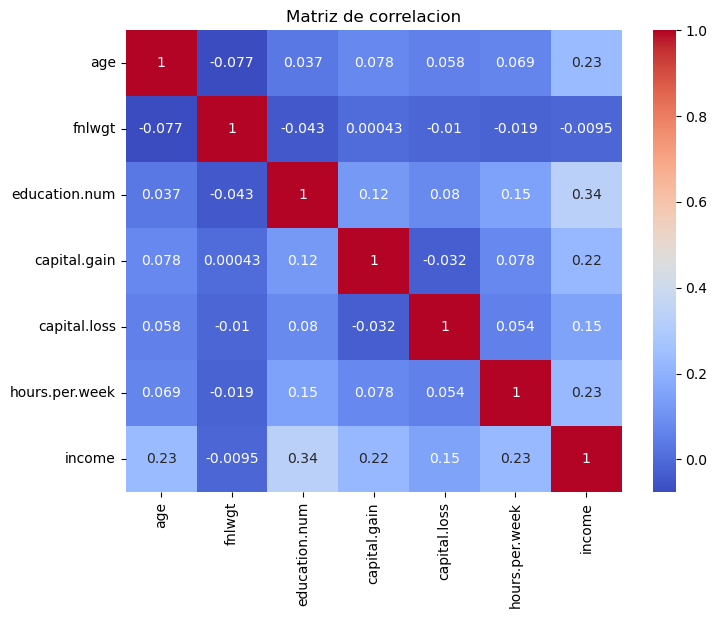

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlacion")
plt.show()

## Parte 6. Selección de variables Predictoras y Variable objetivo

X- Variables que utilizará el modelo

y- Variable que queremos predecir

In [19]:
columnas = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education.num",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "native.country"
]

In [20]:
# Definimos X y
X = dfCensus[columnas]
y = dfCensus["income"]

In [21]:
print(X.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']


In [22]:
print(y.name)

income


In [23]:
print("Numero de variables predictoras:", len(X.columns))

Numero de variables predictoras: 14


## Parte 7. Tratamiento de nulos

El dataset no utiliza `NaN` para representar los valores faltantes, sino el símbolo `"?"`. Antes de poder contarlos como nulos, reemplazamos `"?"` por `NaN`.

Para simplificar el proceso, realizaremos la imputación de los datos antes de la separación TRAIN/TEST.

In [24]:
#Reemplazamos "?" por NaN para poder tratarlos como valores nulos
X = X.replace("?", np.nan)

In [25]:
#Revisamos las variables predictoras
X.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
dtype: int64

In [26]:
#Imputamos las variables categoricas con nulos usando la moda
X["workclass"] = X["workclass"].fillna(
    X["workclass"].mode()[0]
)
X["occupation"] = X["occupation"].fillna(
    X["occupation"].mode()[0]
)
X["native.country"] = X["native.country"].fillna(
    X["native.country"].mode()[0]
)

In [27]:
X.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64

In [28]:
X.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States


## Parte 8. One-Hot Encoding

Los algoritmos no entienden texto. Se deben convertir las variables categóricas en variables numéricas.

In [29]:
columnas_categoricas = X.select_dtypes(include="object").columns.tolist()
columnas_categoricas

['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country']

In [30]:
print("Columnas antes del One-Hot Encoding:", X.shape[1])

Columnas antes del One-Hot Encoding: 14


In [31]:
X = pd.get_dummies(
    X,
    columns = columnas_categoricas,
    drop_first = True
)

In [32]:
print("Columnas despues del One-Hot Encoding:", X.shape[1])

Columnas despues del One-Hot Encoding: 97


In [33]:
X.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,18,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


## Parte 9. Particionamos los datos

No debemos entrenar y evaluar utilizando los mismos datos.

La recomendación es:

Entrenamiento 80%

Pruebas 20%

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)

In [35]:
print("Entrenamiento:", X_train.shape)

Entrenamiento: (26048, 97)


In [36]:
print("Prueba:", X_test.shape)

Prueba: (6513, 97)


## Parte 10. Escalado de las variables

Las variables numéricas tienen valores en escalas muy distintas (por ejemplo age vs capital.gain). El escalado evita que una variable domine más que otra.

In [37]:
variables_numericas

['age',
 'fnlwgt',
 'education.num',
 'capital.gain',
 'capital.loss',
 'hours.per.week']

In [38]:
X_train[variables_numericas].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,26048.000000,2.604800e+04,26048.000000,26048.000000,26048.000000,26048.000000
mean,38.530098,1.902764e+05,10.080505,1086.900683,88.575054,40.420531
std,13.628681,1.061438e+05,2.577431,7413.533054,406.506165,12.325439
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.179830e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.786600e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.381890e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [39]:
scaler = StandardScaler()
X_train[variables_numericas] = scaler.fit_transform(
    X_train[variables_numericas]
)
X_test[variables_numericas] = scaler.transform(
    X_test[variables_numericas]
)

In [40]:
X_train[variables_numericas].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04
mean,4.173566e-17,1.260253e-16,2.858756e-16,1.200241e-17,2.509595e-17,-2.598249e-16
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-1.579794e+00,-1.676922e+00,-3.523151e+00,-1.466132e-01,-2.178977e-01,-3.198368e+00
25%,-7.726573e-01,-6.811022e-01,-4.192259e-01,-1.466132e-01,-2.178977e-01,-3.411963e-02
50%,-1.122726e-01,-1.094421e-01,-3.123527e-02,-1.466132e-01,-2.178977e-01,-3.411963e-02
75%,6.214882e-01,4.514023e-01,7.447460e-01,-1.466132e-01,-2.178977e-01,3.715532e-01
max,3.776660e+00,1.219528e+01,2.296709e+00,1.334236e+01,1.049801e+01,4.752820e+00


## Parte 11. Entrenamiento del modelo

Usaremos un árbol de decisión para clasificar registros.

In [41]:
modelo = DecisionTreeClassifier(
    max_depth = 6,
    random_state = 42,
)

In [42]:
modelo.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Parte 12. Predicciones

Realizamos predicciones para evaluar el modelo.

In [43]:
predicciones = modelo.predict(
    X_test
)

In [44]:
pd.DataFrame({
    "Real": y_test,
    "Prediccion": predicciones
}).head(30)

,Real,Prediccion
10489,<=50K,<=50K
25652,<=50K,<=50K
12243,>50K,>50K
25487,>50K,<=50K
5091,<=50K,<=50K
16449,<=50K,<=50K
23445,<=50K,<=50K
8340,<=50K,<=50K
31373,<=50K,<=50K
25940,<=50K,<=50K


## Parte 13. Evaluación del modelo (Accuracy)

El accuracy determina el porcentaje de predicciones correctas realizadas por el modelo.

In [45]:
accuracy = accuracy_score(
    y_test,
    predicciones
)

In [46]:
print(f"Accuracy: {accuracy: .4f}")

Accuracy:  0.8506


|Accuracy| Interpretación|
|---------|---------------|
| 50% | Adivina |
| 60-70% | Aceptable / Básico |
| 70-80% | Bueno |
| 80-90% | Muy bueno |
| >90% | Excelente (posible sobreajuste) |

## Parte 14. Importancia de las variables

Analizar las variables más relevantes para el algoritmo, al realizar las predicciones.

In [47]:
importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo.feature_importances_ #Que variable es importante para el modelo
})

In [48]:
importancias.sort_values(
    by="Importancia",
    ascending=False
).head(15)

,Variable,Importancia
29,marital.status_Married-civ-spouse,0.440165
2,education.num,0.219832
3,capital.gain,0.208272
4,capital.loss,0.065495
0,age,0.037358
5,hours.per.week,0.021998
51,relationship_Wife,0.003215
1,fnlwgt,0.001591
25,education_Preschool,0.000462
75,native.country_Iran,0.000437


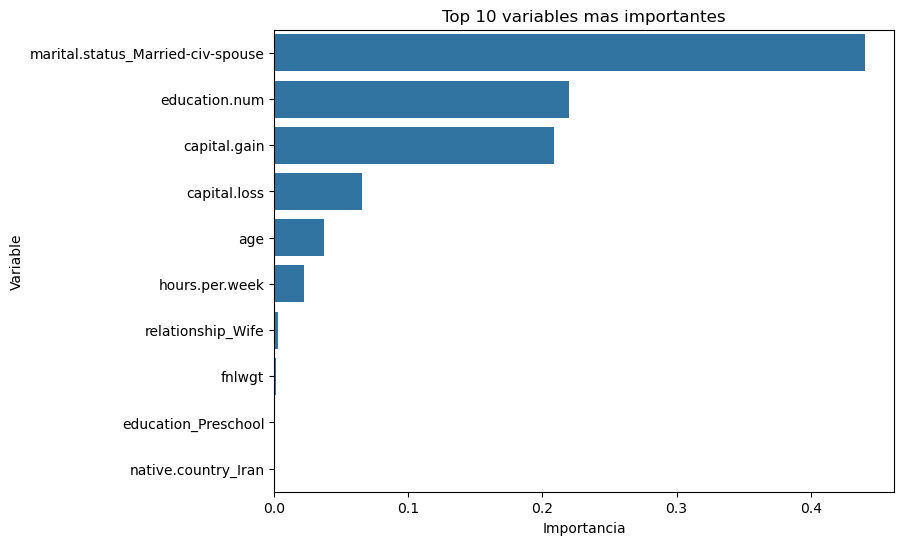

In [49]:
plt.figure(figsize=(8,6))
top_importancias = importancias.sort_values(by="Importancia", ascending=False).head(10)
sns.barplot(
    data=top_importancias,
    x="Importancia",
    y="Variable"
)
plt.title("Top 10 variables mas importantes")
plt.show()

## Parte 15. Preguntas
1.- ¿Cuál es la variable objetivo?
income.

2.- ¿Qué representa dicha variable?
Indica si una persona gana más de 50,000 dólares al año (>50K) o $50,000 o menos (<=50K).

3.- ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
Yo diría que educación, estado civil, horas trabajadas por semana y ocupación, ya que suelen estar relacionadas con el nivel de ingresos. El análisis del lab confirma esto: educación y estado civil (casado) muestran las proporciones más altas de >50K.

4.- ¿Cuántas variables predictoras existen?
14 variables predictoras (antes del One-Hot Encoding).

5.- ¿Por qué fue necesario transformar variables categóricas?
Porque los modelos de Machine Learning (como el árbol de decisión de sklearn) solo trabajan con valores numéricos, entonces las variables tipo texto (como workclass, education, sex, etc.) hay que convertirlas a números mediante One-Hot Encoding.

6.- ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
Se pasó de 14 a 97 columnas, es decir, se generaron 83 columnas adicionales.

7.- ¿Existen valores nulos?
Sí. Originalmente estaban como "?" y al convertirlos a NaN se encontraron nulos en workclass (1836), occupation (1843) y native.country (583). Se imputaron con la moda de cada columna.

8.- ¿Qué variables son numéricas?
age, fnlwgt, education.num, capital.gain, capital.loss, hours.per.week.

9.- ¿Qué variables son categóricas?
workclass, education, marital.status, occupation, relationship, race, sex, native.country.

10.- ¿Cuántos registros quedaron en entrenamiento?
26,048 registros.

11.- ¿Cuántos registros quedaron en prueba?
6,513 registros.

12.- ¿Por qué no debemos entrenar utilizando todos los datos?
Porque si se entrena con todos los datos no habría forma de evaluar qué tan bien generaliza el modelo a datos nuevos; se necesita un conjunto de prueba independiente para medir el desempeño real y evitar el sobreajuste (overfitting).

13.- ¿Cuál fue el Accuracy obtenido?
0.8506 (85.06%).

14.- ¿Consideras que el resultado es adecuado?
Sí, es un buen resultado para un árbol de decisión simple (profundidad 6), aunque hay que tomarlo con cautela porque las clases están desbalanceadas (76% <=50K vs 24% >50K), por lo que el accuracy por sí solo no es suficiente; convendría revisar también precisión, recall o F1.

15.- ¿Qué factores podrían afectar el desempeño del modelo?
El desbalance de clases, la profundidad limitada del árbol (max_depth=6), la imputación de nulos con la moda (que puede introducir sesgo), y la gran cantidad de columnas dummy con poca información (por ejemplo, países con pocos registros).

16.- ¿Cuál fue la variable más importante?
marital.status_Married-civ-spouse (estar casado), con una importancia de 0.44.

17.- ¿Cuál fue la menos importante?
Varias variables tuvieron importancia prácticamente nula, por ejemplo native.country_Guatemala con importancia 0.000000.

18.- ¿Coinciden los resultados con tus hipótesis iniciales?
En parte. Se había planteado que la educación y el estado civil influían en el ingreso, y efectivamente ambas resultaron relevantes (estado civil fue la más importante y education.num la segunda). Sin embargo, no esperaba que capital.gain tuviera tanto peso, y variables como el sexo no aparecieron entre las más importantes pese a mostrar diferencias notables en el análisis exploratorio.

19.- ¿Qué variables aportan más información al modelo?
marital.status_Married-civ-spouse, education.num, capital.gain y capital.loss son las que más aportan, concentrando la mayor parte de la importancia total del modelo.